In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Project** **SetUp**

In [ ]:
!pip install -q kagglehub opencv-python imageio[ffmpeg]

In [ ]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Creating project folder in drive
project_drive = '/content/drive/MyDrive/Violence_Detection_Project'

os.makedirs(project_drive, exist_ok=True)

print(project_drive)

/content/drive/MyDrive/Violence_Detection_Project


In [ ]:
# make dataset accessible in the content folder
import os

dataset_root = os.path.join(
    path,
    "Real Life Violence Dataset"
)

print(dataset_root)
!ln -s "$dataset_root" /content/violence_dataset

/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_142.mp4/Real Life Violence Dataset


# **Dataset Configuration**

In [ ]:
import os
import kagglehub

# Download / locate dataset
dataset_path = kagglehub.dataset_download(
    "mohamedmustafa/real-life-violence-situations-dataset"
)

# Define the correct dataset root
dataset_root = os.path.join(
    dataset_path,
    "Real Life Violence Dataset"
)

# Define class directories
violence_dir = os.path.join(
    dataset_root,
    "Violence"
)

nonviolence_dir = os.path.join(
    dataset_root,
    "NonViolence"
)

print("Dataset path:", dataset_path)
print("Dataset root:", dataset_root)
print("Violence directory:", violence_dir)
print("Non-violence directory:", nonviolence_dir)

print("\nVerification:")
print("Dataset root exists:", os.path.exists(dataset_root))
print("Violence directory exists:", os.path.exists(violence_dir))
print("NonViolence directory exists:", os.path.exists(nonviolence_dir))

print("\nNumber of videos:")
print("Violence:", len(os.listdir(violence_dir)))
print("NonViolence:", len(os.listdir(nonviolence_dir)))

Using Colab cache for faster access to the 'real-life-violence-situations-dataset' dataset.
Dataset path: /kaggle/input/real-life-violence-situations-dataset
Dataset root: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset
Violence directory: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/Violence
Non-violence directory: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence

Verification:
Dataset root exists: True
Violence directory exists: True
NonViolence directory exists: True

Number of videos:
Violence: 1000
NonViolence: 1000


In [ ]:
violence_files = [
    f for f in os.listdir(violence_dir)
    if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))
]

nonviolence_files = [
    f for f in os.listdir(nonviolence_dir)
    if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))
]

print("Violence videos:", len(violence_files))
print("Non-violence videos:", len(nonviolence_files))
print("Total videos:", len(violence_files) + len(nonviolence_files))

Violence videos: 1000
Non-violence videos: 1000
Total videos: 2000


# **3. Explore and Visualize Dataset**

In [ ]:
from IPython.display import HTML
from base64 import b64encode

//function to play video
def play_video(filepath, width=640):
    video = open(filepath, "rb").read()
    data = b64encode(video).decode()

    return HTML(
        f'''
        <video width="{width}" controls>
            <source src="data:video/mp4;base64,{data}" type="video/mp4">
        </video>
        '''
    )

In [ ]:
random_violence = random.choice(violence_files)
random_nonviolence = random.choice(nonviolence_files)

violence_path = os.path.join(
    violence_dir,
    random_violence
)

nonviolence_path = os.path.join(
    nonviolence_dir,
    random_nonviolence
)

print("Random violence video:", random_violence)
print("Random non-violence video:", random_nonviolence)

Random violence video: V_992.mp4
Random non-violence video: NV_69.mp4


In [ ]:
display(play_video(violence_path))

display(play_video(nonviolence_path))

In [ ]:
def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    cap.release()

    duration = frame_count / fps if fps > 0 else 0

    return {
        "fps": fps,
        "frames": frame_count,
        "width": width,
        "height": height,
        "duration": duration
    }

In [ ]:
print("VIOLENCE VIDEO")
print(get_video_info(violence_path))

print("\nNON-VIOLENCE VIDEO")
print(get_video_info(nonviolence_path))

VIOLENCE VIDEO
{'fps': 30.0, 'frames': 150, 'width': 834, 'height': 714, 'duration': 5.0}

NON-VIOLENCE VIDEO
{'fps': 25.0, 'frames': 137, 'width': 854, 'height': 480, 'duration': 5.48}


In [ ]:
# inspecting 20 videos
sample_size = 20

sample_violence = random.sample(
    violence_files,
    min(sample_size, len(violence_files))
)

sample_nonviolence = random.sample(
    nonviolence_files,
    min(sample_size, len(nonviolence_files))
)

In [ ]:
all_stats = []

for filename in sample_violence:
    path = os.path.join(violence_dir, filename)
    info = get_video_info(path)

    if info is not None:
        info["class"] = "Violence"
        info["filename"] = filename
        all_stats.append(info)


for filename in sample_nonviolence:
    path = os.path.join(nonviolence_dir, filename)
    info = get_video_info(path)

    if info is not None:
        info["class"] = "NonViolence"
        info["filename"] = filename
        all_stats.append(info)

In [ ]:
video_stats = pd.DataFrame(all_stats)
video_stats.head()

,fps,frames,width,height,duration,class,filename
0,37.00000,185,224,224,5.000000,Violence,V_622.mp4
1,30.00000,150,416,548,5.000000,Violence,V_801.mp4
2,29.92900,144,360,360,4.811387,Violence,V_381.mp4
3,29.97003,135,1280,720,4.504500,Violence,V_317.mp4
4,30.00000,141,442,720,4.700000,Violence,V_251.mp4


In [ ]:
video_stats.describe()

,fps,frames,width,height,duration
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,27.889880,134.450000,434.550000,363.450000,4.814303
std,5.551431,33.047712,344.930461,193.684908,0.623061
min,11.000000,50.000000,194.000000,224.000000,2.000000
25%,25.000000,115.000000,224.000000,224.000000,4.814162
50%,29.970030,142.500000,224.000000,224.000000,5.000000
75%,30.000000,150.000000,640.000000,480.000000,5.000000
max,37.000000,185.000000,1280.000000,720.000000,5.900000


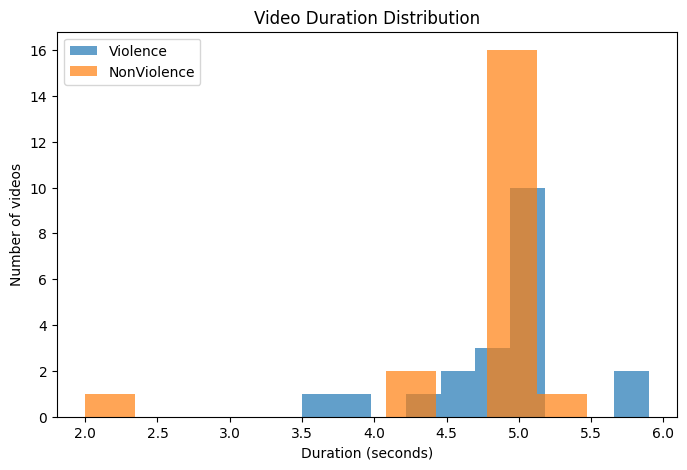

In [ ]:
# Visualize Duration
plt.figure(figsize=(8, 5))

plt.hist(
    video_stats[video_stats["class"] == "Violence"]["duration"],
    bins=10,
    alpha=0.7,
    label="Violence"
)

plt.hist(
    video_stats[video_stats["class"] == "NonViolence"]["duration"],
    bins=10,
    alpha=0.7,
    label="NonViolence"
)

plt.xlabel("Duration (seconds)")
plt.ylabel("Number of videos")
plt.title("Video Duration Distribution")
plt.legend()
plt.show()

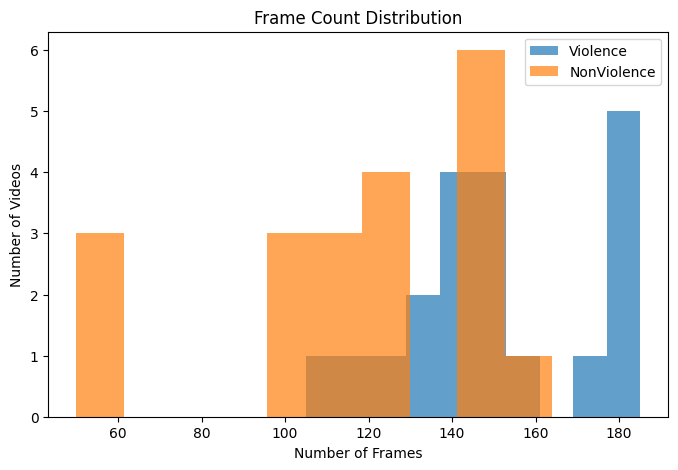

In [ ]:
# Visualize Frame Count
plt.figure(figsize=(8, 5))

plt.hist(
    video_stats[video_stats["class"] == "Violence"]["frames"],
    bins=10,
    alpha=0.7,
    label="Violence"
)

plt.hist(
    video_stats[video_stats["class"] == "NonViolence"]["frames"],
    bins=10,
    alpha=0.7,
    label="NonViolence"
)

plt.xlabel("Number of Frames")
plt.ylabel("Number of Videos")
plt.title("Frame Count Distribution")
plt.legend()
plt.show()

For our dataset, videos are ~5 seconds long with ~140 frames on average, so sampling 16 frames gives a good balance between capturing temporal progression and reducing computational cost.

# **4. Video Preprocessing Strategy**

Each video is converted into a fixed-length sequence of 16 frames.
The frames are resized and preprocessed so that they can be passed
through the pretrained MobileNetV2 feature extractor.

Each video is converted into a fixed-length sequence of 16 frames.
Since videos contain different numbers of frames, 16 frames are
uniformly sampled across the entire video to provide a consistent
temporal representation while keeping computation manageable.

Each selected frame is:
- Converted from BGR to RGB.
- Resized to 224 × 224 pixels to match the input requirements of
  the pretrained MobileNetV2 feature extractor.
- Preprocessed using MobileNetV2's `preprocess_input()` function.

Thus, one video is represented as a tensor of shape:

(16, 224, 224, 3)

where:
- 16 = number of frames in the temporal sequence
- 224 × 224 = spatial dimensions of each frame
- 3 = RGB color channels


# **5. Frame Extraction**

Each video is converted into a fixed-length sequence of 16 frames.
Frames are sampled uniformly across the video's duration, resized to
224 × 224 pixels, converted to RGB, and preprocessed for MobileNetV2.

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
SEQUENCE_LENGTH = 16

In [ ]:
def frames_extraction(video_path):

    frames_list = []

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Could not open video: {video_path}")
        return frames_list

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < SEQUENCE_LENGTH:
        cap.release()
        return frames_list

    # Frame positions we want
    frame_indices = np.linspace(
        0,
        total_frames - 1,
        SEQUENCE_LENGTH,
        dtype=int
    )

    target_indices = set(frame_indices)

    current_frame = 0

    while True:

        success, frame = cap.read()

        if not success:
            break

        if current_frame in target_indices:

            # BGR → RGB
            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            # Resize
            frame = cv2.resize(
                frame,
                (IMAGE_WIDTH, IMAGE_HEIGHT)
            )

            # MobileNetV2 preprocessing
            frame = preprocess_input(
                frame.astype(np.float32)
            )

            frames_list.append(frame)

            # Stop once all required frames are collected
            if len(frames_list) == SEQUENCE_LENGTH:
                break

        current_frame += 1

    cap.release()

    return frames_list

In [ ]:
# Test preprocessing on 1 video
test_video = violence_path

frames = frames_extraction(test_video)

print("Number of extracted frames:", len(frames))

frames_array = np.array(frames)
print("Shape:", frames_array.shape)
print("Data type:", frames_array.dtype)
print("Minimum value:", frames_array.min())
print("Maximum value:", frames_array.max())

Number of extracted frames: 16
Shape: (16, 224, 224, 3)
Data type: float32
Minimum value: -1.0
Maximum value: 1.0


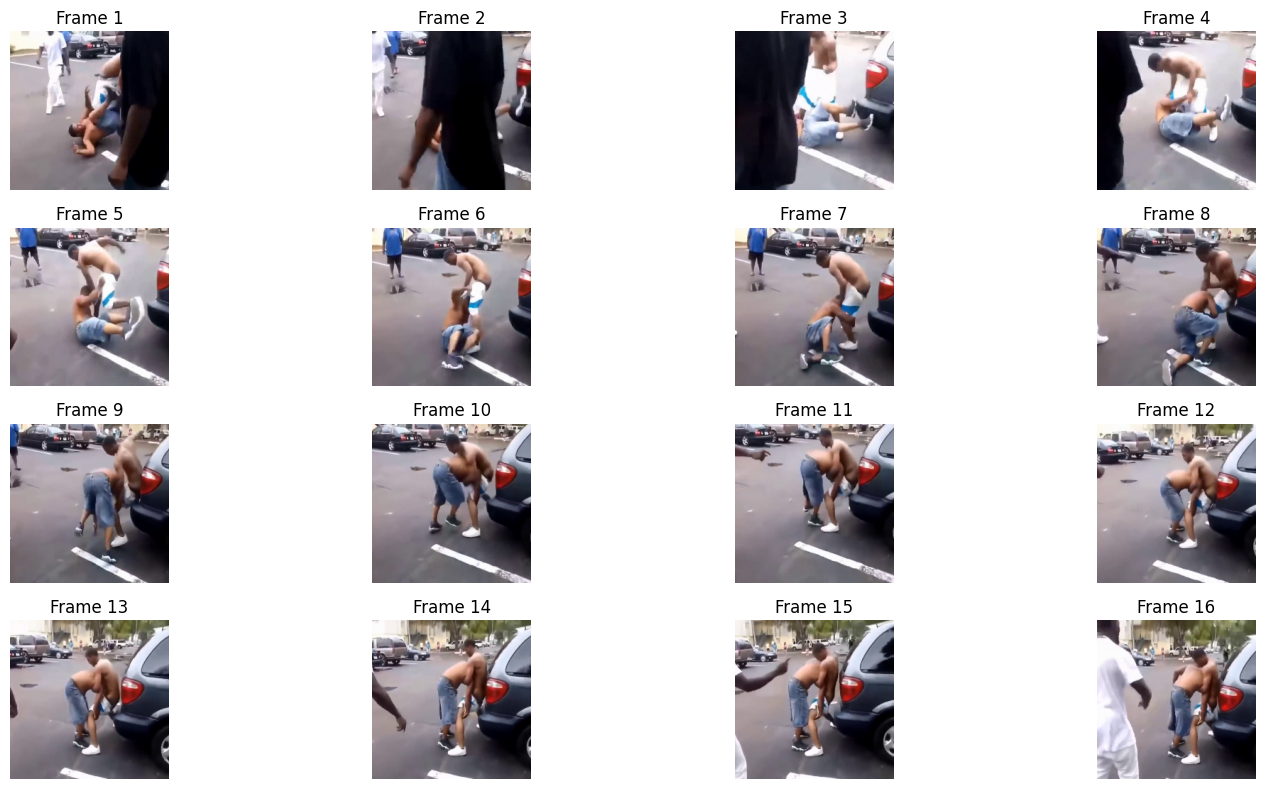

In [ ]:
plt.figure(figsize=(16, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    # Convert approximately back to [0,1] for visualization
    image = (frames_array[i] + 1.0) / 2.0
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    plt.title(f"Frame {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **6 — Dataset Splitting**

In [ ]:
video_data = []

for filename in violence_files:
    video_data.append({
        "filename": filename,
        "path": os.path.join(violence_dir, filename),
        "label": 1,
        "class": "Violence"
    })

for filename in nonviolence_files:
    video_data.append({
        "filename": filename,
        "path": os.path.join(nonviolence_dir, filename),
        "label": 0,
        "class": "NonViolence"
    })

video_df = pd.DataFrame(video_data)

print("Total videos:", len(video_df))
video_df.head()

Total videos: 2000


,filename,path,label,class
0,V_465.mp4,/kaggle/input/real-life-violence-situations-da...,1,Violence
1,V_313.mp4,/kaggle/input/real-life-violence-situations-da...,1,Violence
2,V_753.mp4,/kaggle/input/real-life-violence-situations-da...,1,Violence
3,V_963.mp4,/kaggle/input/real-life-violence-situations-da...,1,Violence
4,V_751.mp4,/kaggle/input/real-life-violence-situations-da...,1,Violence


In [ ]:
print(video_df["class"].value_counts())

class
Violence       1000
NonViolence    1000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(
    video_df,
    test_size=0.15,
    stratify=video_df["label"],     #preserve approximately the same class ratio in every split.
    random_state=42
)
#85% → train + validation
#15% → test

In [ ]:
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.17647,
    stratify=train_val_df["label"],
    random_state=42
)
#0.17647 × 85% ≈ 15% (validation)

In [ ]:
print("Training videos:", len(train_df))
print("Validation videos:", len(val_df))
print("Test videos:", len(test_df))

Training videos: 1400
Validation videos: 300
Test videos: 300


In [ ]:
print("\nTraining:")
print(train_df["class"].value_counts())

print("\nValidation:")
print(val_df["class"].value_counts())

print("\nTest:")
print(test_df["class"].value_counts())


Training:
class
NonViolence    700
Violence       700
Name: count, dtype: int64

Validation:
class
NonViolence    150
Violence       150
Name: count, dtype: int64

Test:
class
NonViolence    150
Violence       150
Name: count, dtype: int64


Next Step: Preprocessing the Dataset

The dataset has now been divided at the video level into training,
validation, and testing sets.

Frame extraction and preprocessing will be performed separately on
each split to prevent data leakage.

The processed data will be saved to Google Drive so that it can be
reused even if the Colab runtime disconnects or resets.

The next stage is to extract 16 frames from each video and use
MobileNetV2 to convert these frames into compact feature vectors.

# **7.MobileNetV2 + BiLSTM Model**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [ ]:
mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

mobilenet.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
frames_array.shape

(16, 224, 224, 3)

In [ ]:
# checking feature shape on 1 previous test video only
features_test = mobilenet.predict(
    frames_array,
    verbose=1
)

print("Feature shape:", features_test.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Feature shape: (16, 1280)


In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    TimeDistributed,
    Bidirectional,
    LSTM,
    Dropout,
    Dense
)

from tensorflow.keras.applications import MobileNetV2

In [ ]:
model = Sequential([

    Input(shape=(16, 224, 224, 3)),

    TimeDistributed(mobilenet),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 16, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       688,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,946,753 (11.24 MB)

 Trainable params: 688,769 (2.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# **8. Data Generator**

In [ ]:
from tensorflow.keras.utils import Sequence

In [ ]:
from tensorflow.keras.utils import Sequence

class VideoDataGenerator(Sequence):

    def __init__(
        self,
        dataframe,
        batch_size=4,
        shuffle=True
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = np.arange(len(self.dataframe))

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, index):

        batch_indices = self.indices[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        X = []
        y = []

        for i in batch_indices:

            # Get information from DataFrame
            row = self.dataframe.iloc[i]

            video_path = row["path"]
            label = row["label"]

            # Use the SAME frame extraction function created and tested in Section 5
            frames = frames_extraction(video_path)

            # Only use the video if exactly SEQUENCE_LENGTH
            # frames were successfully extracted
            if len(frames) == SEQUENCE_LENGTH:

                X.append(frames)
                y.append(label)

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
BATCH_SIZE = 4

train_generator = VideoDataGenerator(
    train_df,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_generator = VideoDataGenerator(
    val_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = VideoDataGenerator(
    test_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
start_time = time.time()

X_batch, y_batch = train_generator[0]

elapsed = time.time() - start_time

print("X shape:", X_batch.shape)
print("y shape:", y_batch.shape)
print("Batch loading time:", round(elapsed, 2), "seconds")

X shape: (4, 16, 224, 224, 3)
y shape: (4,)
Batch loading time: 0.54 seconds


In [ ]:
# TEST GENERATOR
X_batch, y_batch = train_generator[0]

print("X shape:", X_batch.shape)
print("y shape:", y_batch.shape)
print("X dtype:", X_batch.dtype)
print("y:", y_batch)

X shape: (4, 16, 224, 224, 3)
y shape: (4,)
X dtype: float32
y: [0. 0. 1. 0.]


In [ ]:
predictions = model.predict(X_batch, verbose=1)

print("Prediction shape:", predictions.shape)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
Prediction shape: (4, 1)
[[0.56492174]
 [0.4113191 ]
 [0.513771  ]
 [0.6166151 ]]


# **9. Model Training**

The model is trained in two stages.

### Stage 1 — Transfer Learning

MobileNetV2 is kept frozen and its pretrained ImageNet
features are used as a fixed spatial feature extractor.

The Bidirectional LSTM and classification layers are trained
to learn the temporal patterns associated with violence and
non-violence.

### Stage 2 — Fine-Tuning

After establishing the baseline, the last 40 suitable layers
of MobileNetV2 are made trainable using a small learning rate.
This allows the spatial feature extractor to adapt to the
violence-detection task while keeping the earlier general
features intact.

**Frozen Model Training Setup**

In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/DL_Violence_Detection/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)
print("Exists:", os.path.exists(CHECKPOINT_DIR))

Checkpoint directory: /content/drive/MyDrive/DL_Violence_Detection/checkpoints
Exists: True


In [ ]:
print("MobileNetV2 trainable:", mobilenet.trainable)

trainable_layers = sum(
    layer.trainable for layer in mobilenet.layers
)

print("Trainable MobileNetV2 layers:", trainable_layers)
print("Total MobileNetV2 layers:", len(mobilenet.layers))

MobileNetV2 trainable: False
Trainable MobileNetV2 layers: 0
Total MobileNetV2 layers: 155


In [ ]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

In [ ]:
checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "best_frozen_model.keras"
)

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
# Frozen Model 2 epoch test
history_test = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stopping
    ],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7507 - loss: 0.5032 - precision: 0.7327 - recall: 0.8252
Epoch 1: val_loss improved from None to 0.18296, saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_frozen_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_frozen_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 2141s 6s/step - accuracy: 0.8331 - loss: 0.3676 - precision: 0.8166 - recall: 0.8598 - val_accuracy: 0.9400 - val_loss: 0.1830 - val_precision: 0.9521 - val_recall: 0.9267 - learning_rate: 1.0000e-04
Epoch 2/2
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9369 - loss: 0.1715 - precision: 0.9376 - recall: 0.9424
Epoch 2: val_loss improved from 0.18296 to 0.14833, saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_frozen_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_frozen_model.keras
35

After observing the one hour time taken for 2 epochs, we optimized the frames_extraction code

**Fine Tuning Configuration**

In [ ]:
# Freeze all MobileNetV2 layers first
mobilenet.trainable = True

# Freeze all layers except the last 40
for layer in mobilenet.layers[:-40]:
    layer.trainable = False

for layer in mobilenet.layers[-40:]:
    layer.trainable = True

# Verify
trainable_layers = sum(
    layer.trainable for layer in mobilenet.layers
)

print("Total MobileNetV2 layers:", len(mobilenet.layers))
print("Trainable MobileNetV2 layers:", trainable_layers)
print("Frozen MobileNetV2 layers:",
      len(mobilenet.layers) - trainable_layers)

Total MobileNetV2 layers: 155
Trainable MobileNetV2 layers: 40
Frozen MobileNetV2 layers: 115


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
fine_tune_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "best_finetuned_model.keras"
)

fine_tune_checkpoint_callback = ModelCheckpoint(
    fine_tune_checkpoint,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

fine_tune_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2,
    callbacks=[
        fine_tune_checkpoint_callback,
        fine_tune_reduce_lr,
        fine_tune_early_stopping
    ],
    verbose=1
)

Epoch 1/2
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7819 - loss: 0.5545 - precision: 0.8868 - recall: 0.6116
Epoch 1: val_loss improved from None to 0.18239, saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_finetuned_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_finetuned_model.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 600s 1s/step - accuracy: 0.8357 - loss: 0.3971 - precision: 0.8754 - recall: 0.7829 - val_accuracy: 0.9400 - val_loss: 0.1824 - val_precision: 0.9714 - val_recall: 0.9067 - learning_rate: 1.0000e-05
Epoch 2/2
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8515 - loss: 0.3502 - precision: 0.8506 - recall: 0.8593
Epoch 2: val_loss improved from 0.18239 to 0.17824, saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_finetuned_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_finetuned_mod

**Continue Fine-tuning the tuned model**

In [ ]:
# to load the saved checkpoints.
from tensorflow.keras.models import load_model

FROZEN_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "DL_Violence_Detection/checkpoints/"
    "best_frozen_model.keras"
)

FINETUNED_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "DL_Violence_Detection/checkpoints/"
    "best_finetuned_model.keras"
)

frozen_model = load_model(FROZEN_MODEL_PATH)
finetuned_model = load_model(FINETUNED_MODEL_PATH)

print("Both models loaded successfully.")

Both models loaded successfully.


In [ ]:
from tensorflow.keras.optimizers import Adam

finetuned_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
continued_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "best_finetuned_continued.keras"
)

continued_checkpoint_callback = ModelCheckpoint(
    continued_checkpoint,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

continued_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

continued_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
continued_history = finetuned_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=[
        continued_checkpoint_callback,
        continued_reduce_lr,
        continued_early_stopping
    ],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8698 - loss: 0.2891 - precision: 0.8663 - recall: 0.8788
Epoch 1: val_loss improved from None to 0.14356, saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_finetuned_continued.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_finetuned_continued.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 559s 1s/step - accuracy: 0.8829 - loss: 0.2764 - precision: 0.8862 - recall: 0.8786 - val_accuracy: 0.9633 - val_loss: 0.1436 - val_precision: 0.9860 - val_recall: 0.9400 - learning_rate: 1.0000e-05
Epoch 2/3
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9021 - loss: 0.2477 - precision: 0.8752 - recall: 0.9289
Epoch 2: val_loss improved from 0.14356 to 0.14261, saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_finetuned_continued.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_f

In [ ]:
final_candidate_path = os.path.join(
    CHECKPOINT_DIR,
    "final_finetuned_candidate.keras"
)

finetuned_model.save(final_candidate_path)

print("Saved:", final_candidate_path)

Saved: /content/drive/MyDrive/DL_Violence_Detection/checkpoints/final_finetuned_candidate.keras


# **10. Comparing frozen and fine-tuned model on basis of test dataset**

In [ ]:
from tensorflow.keras.models import load_model

frozen_model = load_model(
    "/content/drive/MyDrive/DL_Violence_Detection/checkpoints/best_frozen_model.keras"
)

finetuned_model = load_model(
    "/content/drive/MyDrive/DL_Violence_Detection/checkpoints/final_finetuned_candidate.keras"
)

print("Frozen model loaded.")
print("Fine-tuned model loaded.")

Frozen model loaded.
Fine-tuned model loaded.


In [ ]:
import numpy as np

def get_predictions(model, generator):

    probabilities = []
    true_labels = []

    for i in range(len(generator)):

        X_batch, y_batch = generator[i]

        batch_predictions = model.predict(
            X_batch,
            verbose=0
        )

        probabilities.extend(
            batch_predictions.ravel()
        )

        true_labels.extend(
            y_batch
        )

    probabilities = np.array(probabilities)
    true_labels = np.array(true_labels)

    predicted_labels = (
        probabilities >= 0.5
    ).astype(int)

    return true_labels, predicted_labels, probabilities

In [ ]:
y_true, y_pred_finetuned, y_prob_finetuned = get_predictions(
    finetuned_model,
    test_generator
)

print("True labels shape:", y_true.shape)
print("Predictions shape:", y_pred_finetuned.shape)
print("Probabilities shape:", y_prob_finetuned.shape)

True labels shape: (300,)
Predictions shape: (300,)
Probabilities shape: (300,)


In [ ]:
y_true_frozen, y_pred_frozen, y_prob_frozen = get_predictions(
    frozen_model,
    test_generator
)
print("Frozen predictions:", y_pred_frozen.shape)
print("Fine-tuned predictions:", y_pred_finetuned.shape)

Frozen predictions: (300,)
Fine-tuned predictions: (300,)


**Evaluation Metrics**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
def calculate_metrics(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return accuracy, precision, recall, f1

In [ ]:
frozen_metrics = calculate_metrics(
    y_true_frozen,
    y_pred_frozen
)

finetuned_metrics = calculate_metrics(
    y_true,
    y_pred_finetuned
)

print("Frozen Model")
print("Accuracy :", frozen_metrics[0])
print("Precision:", frozen_metrics[1])
print("Recall   :", frozen_metrics[2])
print("F1-score :", frozen_metrics[3])

print("\nFine-Tuned Model")
print("Accuracy :", finetuned_metrics[0])
print("Precision:", finetuned_metrics[1])
print("Recall   :", finetuned_metrics[2])
print("F1-score :", finetuned_metrics[3])

Frozen Model
Accuracy : 0.93
Precision: 0.9161290322580645
Recall   : 0.9466666666666667
F1-score : 0.9311475409836065

Fine-Tuned Model
Accuracy : 0.96
Precision: 0.9726027397260274
Recall   : 0.9466666666666667
F1-score : 0.9594594594594594


In [ ]:
print(
    f"Frozen Model Accuracy: "
    f"{frozen_metrics[0] * 100:.2f}%"
)

print(
    f"Fine-Tuned Model Accuracy: "
    f"{finetuned_metrics[0] * 100:.2f}%"
)

Frozen Model Accuracy: 93.00%
Fine-Tuned Model Accuracy: 96.00%


In [ ]:
cm_frozen = confusion_matrix(
    y_true_frozen,
    y_pred_frozen
)

cm_finetuned = confusion_matrix(
    y_true,
    y_pred_finetuned
)

print("Frozen Model Confusion Matrix:")
print(cm_frozen)

print("\nFine-Tuned Model Confusion Matrix:")
print(cm_finetuned)

Frozen Model Confusion Matrix:
[[137  13]
 [  8 142]]

Fine-Tuned Model Confusion Matrix:
[[146   4]
 [  8 142]]


In [ ]:
print("FINE-TUNED MODEL")
print(
    classification_report(
        y_true,
        y_pred_finetuned,
        target_names=["NonViolence", "Violence"],
        digits=4
    )
)

FINE-TUNED MODEL
              precision    recall  f1-score   support

 NonViolence     0.9481    0.9733    0.9605       150
    Violence     0.9726    0.9467    0.9595       150

    accuracy                         0.9600       300
   macro avg     0.9603    0.9600    0.9600       300
weighted avg     0.9603    0.9600    0.9600       300



In [ ]:
print("FROZEN MODEL")
print(
    classification_report(
        y_true_frozen,
        y_pred_frozen,
        target_names=["NonViolence", "Violence"],
        digits=4
    )
)

FROZEN MODEL
              precision    recall  f1-score   support

 NonViolence     0.9448    0.9133    0.9288       150
    Violence     0.9161    0.9467    0.9311       150

    accuracy                         0.9300       300
   macro avg     0.9305    0.9300    0.9300       300
weighted avg     0.9305    0.9300    0.9300       300



# **11 - Single Video Prediction**

In [ ]:
from tensorflow.keras.models import load_model
import os

FINAL_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "final_finetuned_candidate.keras"
)

final_model = load_model(FINAL_MODEL_PATH)

print("Final model loaded successfully.")
print("Model path:", FINAL_MODEL_PATH)

Final model loaded successfully.
Model path: /content/drive/MyDrive/DL_Violence_Detection/checkpoints/final_finetuned_candidate.keras


In [ ]:
def predict_video(model, video_path):

    frames = frames_extraction(video_path)

    if len(frames) != SEQUENCE_LENGTH:
        return None, None

    X = np.expand_dims(
        np.array(frames),
        axis=0
    )

    probability = float(
        model.predict(X, verbose=0)[0][0]
    )

    if probability >= 0.5:
        predicted_class = "Violence"
        confidence = probability
    else:
        predicted_class = "NonViolence"
        confidence = 1 - probability

    return predicted_class, confidence

In [ ]:
sample_video_path = test_df["path"].iloc[298]

sample_video_label = test_df["class"].iloc[298]

print("Video:", sample_video_path)
print("Actual class:", sample_video_label)

Video: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/Violence/V_246.mp4
Actual class: Violence


In [ ]:
display(play_video(sample_video_path))

In [ ]:
predicted_class, confidence = predict_video(
    final_model,
    sample_video_path
)

print("Actual class     :", sample_video_label)
print("Predicted class  :", predicted_class)
print("Confidence       :", f"{confidence * 100:.2f}%")

Actual class     : Violence
Predicted class  : Violence
Confidence       : 88.28%


In [ ]:
violence_test_video = os.path.join(
    violence_dir,
    "V_250.mp4"
)

nonviolence_test_video = os.path.join(
    nonviolence_dir,
    "NV_731.mp4"
)


predicted_class, confidence = predict_video(
    final_model,
    violence_test_video
)
print("Actual class    : Violence")
print("Predicted class : ", predicted_class)
print("Confidence      : ", f"{confidence * 100:.2f}%")


predicted_class, confidence = predict_video(
    final_model,
    nonviolence_test_video
)
print("Actual class    : NonViolence")
print("Predicted class : ", predicted_class)
print("Confidence      : ", f"{confidence * 100:.2f}%")

Actual class    : Violence
Predicted class :  Violence
Confidence      :  90.63%
Actual class    : NonViolence
Predicted class :  NonViolence
Confidence      :  99.13%
